In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
df=pd.read_csv(r"C:\Users\UTKARSH SINGH\OneDrive\Desktop\Data Science\dirty_cafe_sales.csv")

In [51]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [52]:
df.shape

(10000, 8)

In [53]:
data={
"Date":"Date of transaction",    
"Transaction ID	": "Transaction ID of the bill",
"Item":"Item purchased by the customer",
"Quantity":"Quantity of items purchased by customer",
"Price Per Unit":"price per unit item",
"Total Spent":"Total amount spent by customer",
"Payment Method":"Payment method of the customer",
"Location":"Location where the customer has bought the item"
}

In [54]:
df.duplicated().sum()

np.int64(0)

In [55]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [56]:
x=df['Transaction Date']
df.drop("Transaction Date",axis=1,inplace=True)

In [57]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store
...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN


In [58]:
s=['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location']


In [59]:
a=np.c_[x,df]

In [60]:
a=pd.DataFrame(a,columns=['Date']+s)

In [61]:
a

,Date,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location
0,2023-09-08,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway
1,2023-05-16,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store
2,2023-07-19,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store
3,2023-04-27,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN
4,2023-06-11,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store
...,...,...,...,...,...,...,...,...
9995,2023-08-30,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN
9996,2023-06-02,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN
9997,2023-03-02,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN
9998,2023-12-02,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN


In [62]:
list=['Item','Payment Method','Location']

In [63]:
for i in list:
    a[i]=a[i].fillna(a[i].mode()[0])

In [64]:
a.isnull().sum()

Date              159
Transaction ID      0
Item                0
Quantity          138
Price Per Unit    179
Total Spent       173
Payment Method      0
Location            0
dtype: int64

In [65]:
a['Price Per Unit'].value_counts()

Price Per Unit
3.0        2429
4.0        2331
2.0        1227
5.0        1204
1.0        1143
1.5        1133
ERROR       190
UNKNOWN     164
Name: count, dtype: int64

In [66]:
list2=['Quantity','Price Per Unit','Total Spent']

In [67]:
for i in list2:
    a[i]=pd.to_numeric(a[i],errors="coerce")

In [68]:
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            9841 non-null   object 
 1   Transaction ID  10000 non-null  object 
 2   Item            10000 non-null  object 
 3   Quantity        9521 non-null   float64
 4   Price Per Unit  9467 non-null   float64
 5   Total Spent     9498 non-null   float64
 6   Payment Method  10000 non-null  object 
 7   Location        10000 non-null  object 
dtypes: float64(3), object(5)
memory usage: 625.1+ KB


In [69]:
a['Date'].head(50)

0     2023-09-08
1     2023-05-16
2     2023-07-19
3     2023-04-27
4     2023-06-11
5     2023-03-31
6     2023-10-06
7     2023-10-28
8     2023-07-28
9     2023-12-31
10    2023-11-07
11         ERROR
12    2023-05-03
13    2023-06-01
14    2023-03-21
15    2023-11-15
16    2023-06-10
17    2023-02-24
18    2023-03-25
19    2023-01-15
20    2023-04-04
21    2023-03-30
22    2023-12-01
23    2023-09-18
24    2023-06-03
25    2023-12-13
26    2023-04-20
27    2023-04-10
28    2023-03-11
29         ERROR
30    2023-06-02
31    2023-11-06
32    2023-08-15
33         ERROR
34    2023-10-09
35    2023-05-28
36    2023-07-17
37    2023-04-29
38    2023-06-08
39    2023-06-29
40    2023-04-17
41    2023-12-22
42    2023-01-10
43    2023-10-02
44    2023-02-23
45    2023-03-22
46    2023-11-03
47    2023-03-02
48    2023-06-26
49    2023-05-02
Name: Date, dtype: object

In [70]:
a['Date']=pd.to_datetime(a['Date'],errors='coerce')

In [71]:
a['Date'].head(50)

0    2023-09-08
1    2023-05-16
2    2023-07-19
3    2023-04-27
4    2023-06-11
5    2023-03-31
6    2023-10-06
7    2023-10-28
8    2023-07-28
9    2023-12-31
10   2023-11-07
11          NaT
12   2023-05-03
13   2023-06-01
14   2023-03-21
15   2023-11-15
16   2023-06-10
17   2023-02-24
18   2023-03-25
19   2023-01-15
20   2023-04-04
21   2023-03-30
22   2023-12-01
23   2023-09-18
24   2023-06-03
25   2023-12-13
26   2023-04-20
27   2023-04-10
28   2023-03-11
29          NaT
30   2023-06-02
31   2023-11-06
32   2023-08-15
33          NaT
34   2023-10-09
35   2023-05-28
36   2023-07-17
37   2023-04-29
38   2023-06-08
39   2023-06-29
40   2023-04-17
41   2023-12-22
42   2023-01-10
43   2023-10-02
44   2023-02-23
45   2023-03-22
46   2023-11-03
47   2023-03-02
48   2023-06-26
49   2023-05-02
Name: Date, dtype: datetime64[ns]

In [72]:
a['Date'].isnull().sum()

np.int64(460)

In [73]:
a['Date']=a['Date'].fillna(a['Date'].mode()[0])

In [74]:
a['Date'].isnull().sum()

np.int64(0)

In [75]:
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            10000 non-null  datetime64[ns]
 1   Transaction ID  10000 non-null  object        
 2   Item            10000 non-null  object        
 3   Quantity        9521 non-null   float64       
 4   Price Per Unit  9467 non-null   float64       
 5   Total Spent     9498 non-null   float64       
 6   Payment Method  10000 non-null  object        
 7   Location        10000 non-null  object        
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 625.1+ KB


In [76]:
for i in list2:
    a[i]=a[i].fillna(a[i].median())

In [77]:
a.isnull().sum()

Date              0
Transaction ID    0
Item              0
Quantity          0
Price Per Unit    0
Total Spent       0
Payment Method    0
Location          0
dtype: int64

In [78]:
a

,Date,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location
0,2023-09-08,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway
1,2023-05-16,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store
2,2023-07-19,TXN_4271903,Cookie,4.0,1.0,8.0,Credit Card,In-store
3,2023-04-27,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN
4,2023-06-11,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store
...,...,...,...,...,...,...,...,...
9995,2023-08-30,TXN_7672686,Coffee,2.0,2.0,4.0,Digital Wallet,UNKNOWN
9996,2023-06-02,TXN_9659401,Juice,3.0,3.0,3.0,Digital Wallet,Takeaway
9997,2023-03-02,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,Takeaway
9998,2023-12-02,TXN_7695629,Cookie,3.0,3.0,3.0,Digital Wallet,Takeaway


In [79]:
m=['Date', 'Transaction ID', 'Item', 'Quantity', 'Price Per Unit',
       'Total Spent', 'Payment Method', 'Location']

<Axes: >

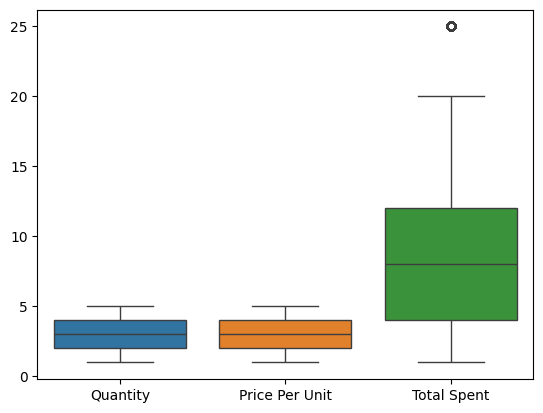

In [80]:
sns.boxplot(a)

C:\Users\UTKARSH SINGH\AppData\Local\Temp\ipykernel_1648\2552946121.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a['Total Spent'])


<Axes: xlabel='Total Spent', ylabel='Density'>

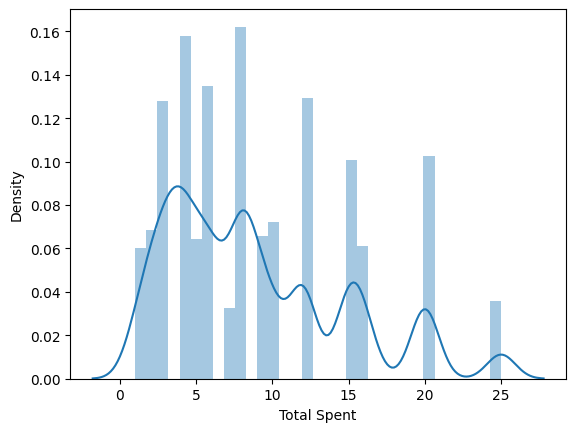

In [81]:
sns.distplot(a['Total Spent'])

C:\Users\UTKARSH SINGH\AppData\Local\Temp\ipykernel_1648\3417554996.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a['Quantity'])


<Axes: xlabel='Quantity', ylabel='Density'>

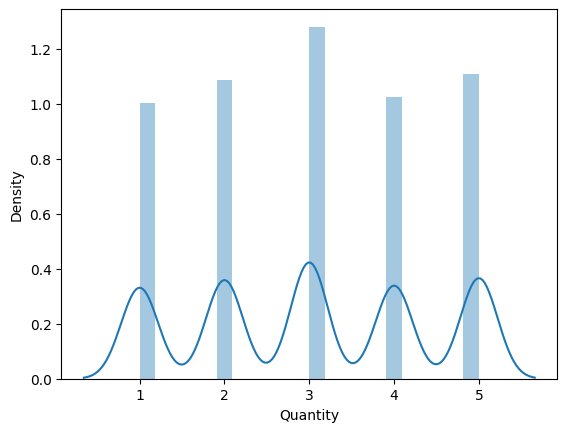

In [82]:
sns.distplot(a['Quantity'])

C:\Users\UTKARSH SINGH\AppData\Local\Temp\ipykernel_1648\474227577.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(a['Price Per Unit'])


<Axes: xlabel='Price Per Unit', ylabel='Density'>

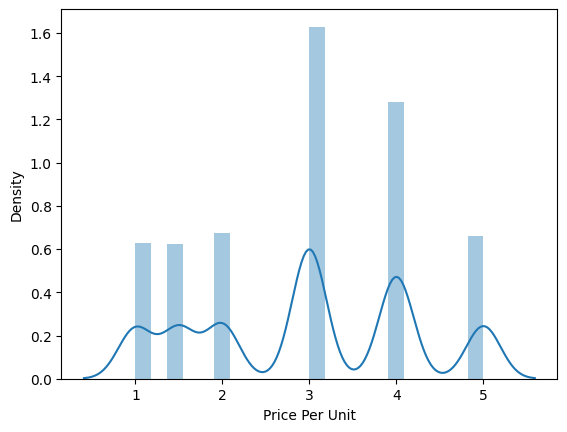

In [83]:
sns.distplot(a['Price Per Unit'])

In [84]:
list3=['Transaction ID', 'Item', 'Payment Method', 'Location']

In [85]:
for i in list3:
    a[i]=a[i].str.strip()
    a[i]=a[i].str.lower()

In [86]:
a

,Date,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location
0,2023-09-08,txn_1961373,coffee,2.0,2.0,4.0,credit card,takeaway
1,2023-05-16,txn_4977031,cake,4.0,3.0,12.0,cash,in-store
2,2023-07-19,txn_4271903,cookie,4.0,1.0,8.0,credit card,in-store
3,2023-04-27,txn_7034554,salad,2.0,5.0,10.0,unknown,unknown
4,2023-06-11,txn_3160411,coffee,2.0,2.0,4.0,digital wallet,in-store
...,...,...,...,...,...,...,...,...
9995,2023-08-30,txn_7672686,coffee,2.0,2.0,4.0,digital wallet,unknown
9996,2023-06-02,txn_9659401,juice,3.0,3.0,3.0,digital wallet,takeaway
9997,2023-03-02,txn_5255387,coffee,4.0,2.0,8.0,digital wallet,takeaway
9998,2023-12-02,txn_7695629,cookie,3.0,3.0,3.0,digital wallet,takeaway
